<a href="https://colab.research.google.com/github/lavanya-613/Movie-App/blob/main/labs/lab01/lab01_selfie_studio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎨 BITS F459 — Build Your Own Instagram

**Computer Vision · Week 1**

Every photo filter you have ever used is **arithmetic on a grid of numbers**. Today you write them yourself.

# 📸 Lab 1 — Every Image Operation, Live on Your Face

**BITS F459 Computer Vision · Week 1 · BITS Pilani Dubai**

Take a selfie once. Then run all ten operations from the lecture on it, with sliders.

| | Operation | Slide | | | Operation | Slide |
|--|-----------|:-----:|--|--|-----------|:-----:|
| 1 | Brightness | 40 | | 6 | Rotation | 45 |
| 2 | Contrast | 41 | | 7 | Flipping | 46 |
| 3 | Arithmetic & blending | 42 | | 8 | Thresholding | 47 |
| 4 | Translation | 43 | | 9 | Blurring | 48 |
| 5 | Scaling | 44 | | 10 | Sharpening | 50–53 |


## ⚙️ Setup — run once

In [1]:
import numpy as np, matplotlib.pyplot as plt, cv2
from base64 import b64decode
from ipywidgets import interact, IntSlider, FloatSlider, Dropdown, Checkbox

def take_selfie(quality=0.92):
    from IPython.display import display, Javascript
    from google.colab.output import eval_js
    display(Javascript("""
      async function takePhoto(quality) {
        const div = document.createElement('div');
        const btn = document.createElement('button');
        btn.textContent = '📸  CLICK TO CAPTURE';
        btn.style.cssText = 'padding:12px 22px;font-size:16px;margin:8px;cursor:pointer';
        const video = document.createElement('video');
        video.style.cssText = 'display:block;max-width:420px';
        const stream = await navigator.mediaDevices.getUserMedia({video:true});
        div.appendChild(btn); div.appendChild(video);
        document.body.appendChild(div);
        video.srcObject = stream; await video.play();
        google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
        await new Promise(r => btn.onclick = r);
        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth; canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);
        stream.getVideoTracks()[0].stop(); div.remove();
        return canvas.toDataURL('image/jpeg', quality);
      }"""))
    d = eval_js(f'takePhoto({quality})')
    buf = np.frombuffer(b64decode(d.split(',')[1]), np.uint8)
    return cv2.cvtColor(cv2.imdecode(buf, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)

def upload_photo():
    from google.colab import files
    up = files.upload()
    buf = np.frombuffer(list(up.values())[0], np.uint8)
    return cv2.cvtColor(cv2.imdecode(buf, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)

def show(*pairs, size=4.2, cmap=None):
    """show((image, 'title'), (image, 'title'), ...)"""
    n = len(pairs)
    fig, ax = plt.subplots(1, n, figsize=(size*n, size))
    ax = np.atleast_1d(ax)
    for a, (im, t) in zip(ax, pairs):
        a.imshow(im, cmap="gray" if (im.ndim == 2 and cmap is None) else cmap,
                 vmin=0, vmax=255)
        a.set_title(t, fontsize=11); a.axis("off")
    plt.tight_layout(); plt.show()

u8   = lambda a: np.clip(a, 0, 255).astype(np.uint8)
grey_of = lambda im: u8(0.299*im[:,:,0] + 0.587*im[:,:,1] + 0.114*im[:,:,2])
print("Ready.")

Ready.


## 📷 Take your selfie

Click **CLICK TO CAPTURE** when the camera appears, and allow the camera if the browser asks.

*Camera blocked?* Change `"camera"` to `"upload"` and pick a photo — everything below still works.

<IPython.core.display.Javascript object>

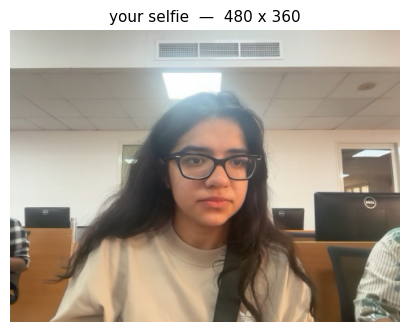

This is now an array of shape (360, 480, 3) — just numbers.


In [4]:
SOURCE = "camera"          # "camera"  or  "upload"

img = take_selfie() if SOURCE == "camera" else upload_photo()
img = cv2.resize(img, (480, int(480*img.shape[0]/img.shape[1])))
H, W = img.shape[:2]
grey = grey_of(img)

show((img, f"your selfie  —  {W} x {H}"))
print("This is now an array of shape", img.shape, "— just numbers.")

---
# 🎚️ Group 1 · Point operations
### Operations 1–3 — slides 40, 41, 42

Every pixel is changed **on its own**, ignoring its neighbours.

$$\text{brightness } g = f + \beta \qquad \text{contrast } g = \alpha f \qquad \text{blend } g = \lambda f_1 + (1-\lambda) f_2$$

In [5]:
mirror = np.fliplr(img).copy()      # the second image, for arithmetic

def point_ops(beta=0, alpha=1.0, mode="none", lam=0.5):
    out = img.astype(np.float32)*alpha + beta                      # 1 + 2
    if mode == "add":      out = out + mirror                      # 3
    elif mode == "subtract": out = out - mirror
    elif mode == "blend":  out = lam*out + (1-lam)*mirror
    show((img, "original"), (u8(out), f"beta={beta}  alpha={alpha}  {mode}"))

interact(point_ops,
         beta  = IntSlider(value=0, min=-120, max=120, step=5, description="1 brightness"),
         alpha = FloatSlider(value=1.0, min=0.2, max=3.0, step=0.1, description="2 contrast"),
         mode  = Dropdown(options=["none","add","subtract","blend"], description="3 arithmetic"),
         lam   = FloatSlider(value=0.5, min=0.0, max=1.0, step=0.05, description="   lambda"));

interactive(children=(IntSlider(value=0, description='1 brightness', max=120, min=-120, step=5), FloatSlider(v…

---
# 🔄 Group 2 · Geometric operations
### Operations 4–7 — slides 43, 44, 45, 46

Pixel **values** are untouched — only their **positions** move.

$$\text{translate }(x', y') = (x + t_x,\; y + t_y) \qquad \text{flip } x' = W - 1 - x$$

In [6]:
def geometry(tx=0, ty=0, scale=1.0, angle=0, flip="none"):
    out = img.copy()

    if flip in ("horizontal", "both"): out = np.fliplr(out)         # 7
    if flip in ("vertical",   "both"): out = np.flipud(out)

    M = cv2.getRotationMatrix2D((W/2, H/2), angle, scale)           # 5 + 6
    M[0, 2] += tx                                                   # 4
    M[1, 2] += ty
    out = cv2.warpAffine(out, M, (W, H))

    show((img, "original"),
         (out, f"tx={tx} ty={ty}  scale={scale}  angle={angle}  flip={flip}"))

interact(geometry,
         tx    = IntSlider(value=0, min=-200, max=200, step=10, description="4 shift x"),
         ty    = IntSlider(value=0, min=-200, max=200, step=10, description="4 shift y"),
         scale = FloatSlider(value=1.0, min=0.2, max=3.0, step=0.1, description="5 scale"),
         angle = IntSlider(value=0, min=-180, max=180, step=5, description="6 rotate"),
         flip  = Dropdown(options=["none","horizontal","vertical","both"], description="7 flip"));

interactive(children=(IntSlider(value=0, description='4 shift x', max=200, min=-200, step=10), IntSlider(value…

---
# 🔍 Group 3 · Neighbourhood operations
### Operations 8–10 — slides 47, 48, 50–53

Now a pixel's new value depends on the pixels **around** it.

$$g(x,y) = \sum_i \sum_j K(i,j)\, f(x+i,\; y+j)$$

In [7]:
KERNELS = {
    "none":    None,
    "blur 3x3":  np.ones((3,3), np.float32)/9,
    "blur 9x9":  np.ones((9,9), np.float32)/81,
    "sharpen":   np.array([[0,-1,0],[-1, 5,-1],[0,-1,0]], np.float32),
    "edge":      np.array([[0,-1,0],[-1, 4,-1],[0,-1,0]], np.float32),
}

def neighbourhood(kernel="none", T=0):
    out = grey.astype(np.float32)
    if kernel != "none":                                           # 9 + 10
        out = cv2.filter2D(out, -1, KERNELS[kernel])
        if kernel == "edge": out = np.abs(out)
    if T > 0:                                                      # 8
        out = np.where(out >= T, 255, 0)
    show((grey, "grayscale"), (u8(out), f"{kernel}   threshold T={T}"))
    if kernel != "none":
        print(f"{kernel} kernel:\n{KERNELS[kernel]}\nweights sum to {KERNELS[kernel].sum():.2f}")

interact(neighbourhood,
         kernel = Dropdown(options=list(KERNELS), description="9/10 kernel"),
         T      = IntSlider(value=0, min=0, max=255, step=5, description="8 threshold"));

interactive(children=(Dropdown(description='9/10 kernel', options=('none', 'blur 3x3', 'blur 9x9', 'sharpen', …

## 🖼️ All ten at once — screenshot this 📸

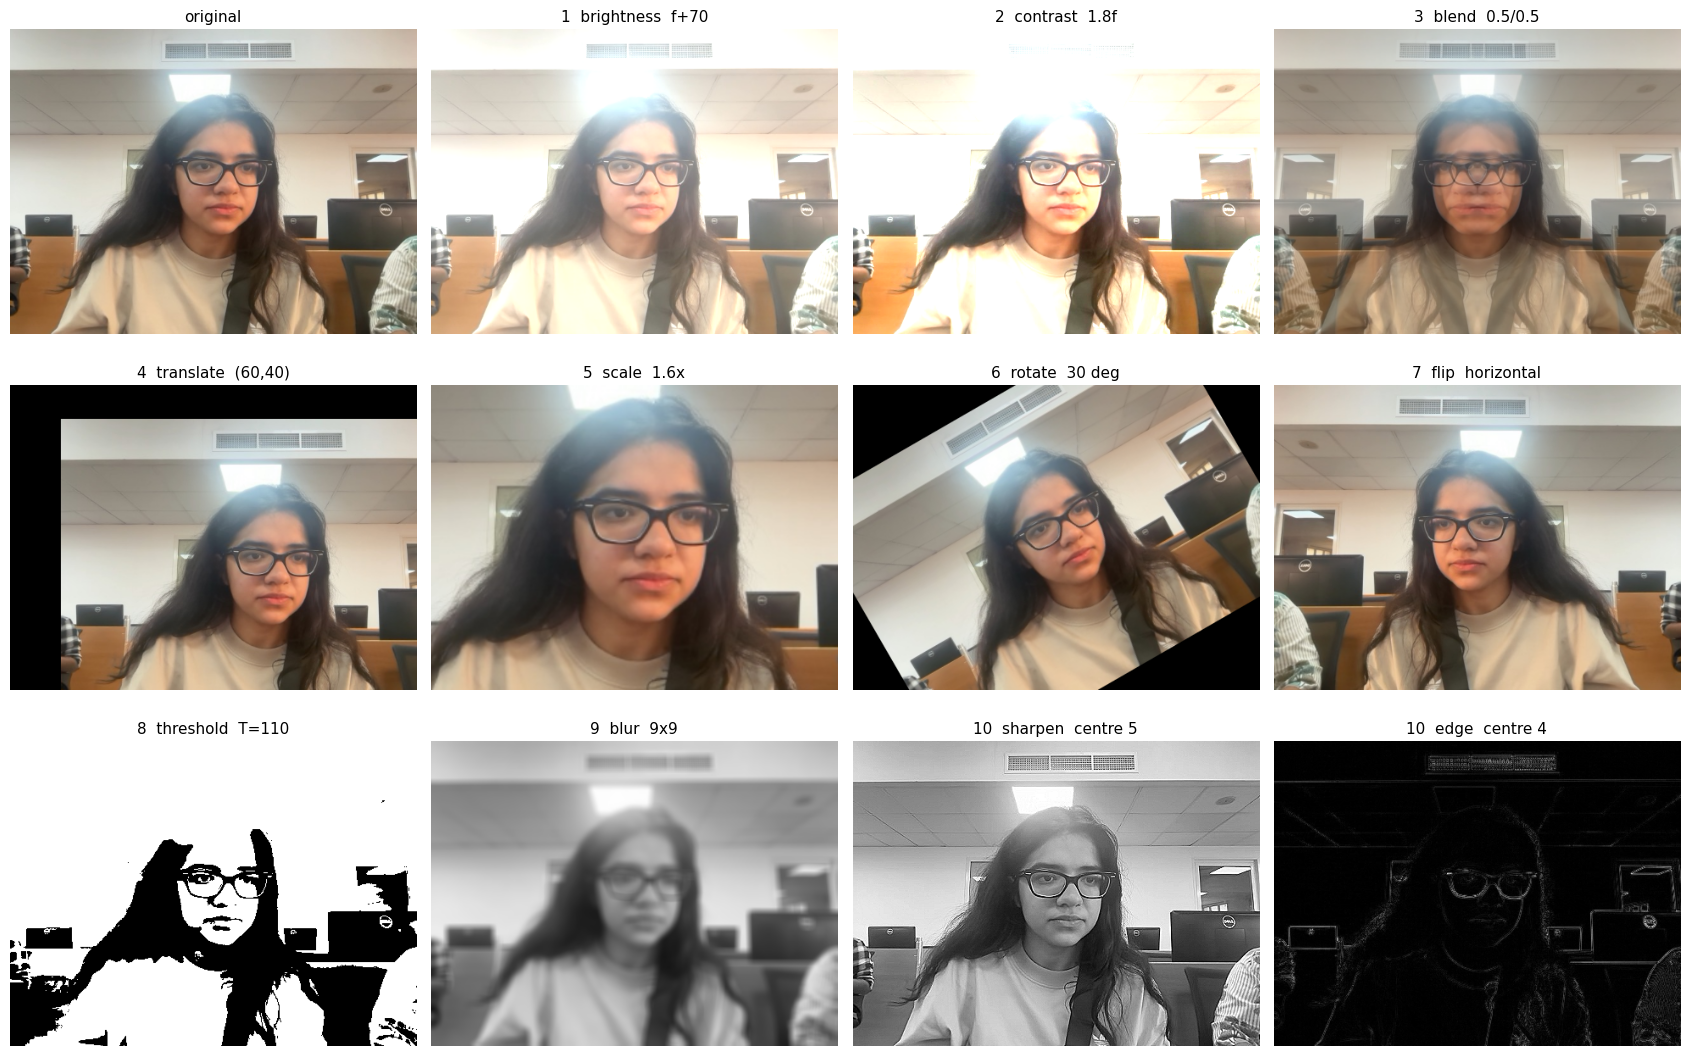

In [8]:
g3 = lambda a: cv2.cvtColor(u8(a), cv2.COLOR_GRAY2RGB)
M_rot = cv2.getRotationMatrix2D((W/2, H/2), 30, 1.0)
M_tr  = np.float32([[1,0,60],[0,1,40]])
M_sc  = cv2.getRotationMatrix2D((W/2, H/2), 0, 1.6)
f     = grey.astype(np.float32)

tiles = [
    (img,                                             "original"),
    (u8(img.astype(np.int16) + 70),                   "1  brightness  f+70"),
    (u8(img.astype(np.float32)*1.8),                  "2  contrast  1.8f"),
    (u8(0.5*img + 0.5*np.fliplr(img)),                "3  blend  0.5/0.5"),
    (cv2.warpAffine(img, M_tr, (W,H)),                "4  translate  (60,40)"),
    (cv2.warpAffine(img, M_sc, (W,H)),                "5  scale  1.6x"),
    (cv2.warpAffine(img, M_rot, (W,H)),               "6  rotate  30 deg"),
    (np.fliplr(img),                                  "7  flip  horizontal"),
    (g3(np.where(grey >= 110, 255, 0)),               "8  threshold  T=110"),
    (g3(cv2.filter2D(f, -1, KERNELS["blur 9x9"])),    "9  blur  9x9"),
    (g3(cv2.filter2D(f, -1, KERNELS["sharpen"])),     "10  sharpen  centre 5"),
    (g3(np.abs(cv2.filter2D(f, -1, KERNELS["edge"]))),"10  edge  centre 4"),
]

fig, ax = plt.subplots(3, 4, figsize=(17,11))
for a, (im, t) in zip(ax.ravel(), tiles):
    a.imshow(im); a.axis("off"); a.set_title(t, fontsize=11)
plt.tight_layout(); plt.show()

---
## 👀 Before you leave — compare the last two

```
sharpen              edge
 0 -1  0            0 -1  0
-1  5 -1           -1  4 -1
 0 -1  0            0 -1  0
```

**One number.** 5 versus 4.

The edge kernel's weights add up to **0** — flat areas vanish, and only *change* survives.
The sharpen kernel adds up to **1** — the picture stays, and its changes get amplified.

Every operation today was one of three kinds:

| Kind | Depends on | Operations |
|------|-----------|-----------|
| **Point** | the pixel itself | brightness, contrast, arithmetic, threshold |
| **Geometric** | where the pixel is | translate, scale, rotate, flip |
| **Neighbourhood** | the pixels around it | blur, sharpen, edge |

That third kind is the one that keeps going: it becomes edge and corner detection in **Week 2**, and convolutional layers in **Week 6**.